# Oil Price Analysis - Task 1: Data Preparation & EDA

This notebook covers the first phase of the project: loading, cleaning, and exploring the oil price dataset.

---

## Setup

Import all necessary modules and configure display settings.

In [1]:
# Import modules
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add src to path if running from notebooks directory and package is not installed
sys.path.append(str(Path.cwd().parent / 'src'))

# Import our custom modules
from data import load_oil_data, clean_data, prepare_data_for_modeling
from eda import calculate_statistics, plot_time_series, plot_distribution, plot_volatility

# Configure matplotlib for inline display

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All modules imported successfully!")

✓ All modules imported successfully!


---

## Step 1: Load and Prepare Data

Load the oil price dataset and prepare it for analysis.

In [2]:
# Define data path
data_path = Path('../data/BrentOilPrices.csv')

# Load data
print("Loading oil price data...")
if not data_path.exists():
    print(f"Error: Data file not found at {data_path.absolute()}")
else:
    df = load_oil_data(data_path)
    print(f"✓ Loaded {len(df)} records\n")

    # Display first few rows
    print("First 5 rows:")
    display(df.head())

Loading oil price data...
✓ Loaded 9011 records

First 5 rows:


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [3]:
# Clean data
print("Cleaning data...")
df_clean = clean_data(df)
print(f"✓ Cleaned data: {len(df_clean)} records")

# Prepare for modeling
print("\nPreparing data for modeling...")
data_dict = prepare_data_for_modeling(df_clean)

print(f"\n{'='*50}")
print("DATA SUMMARY")
print(f"{'='*50}")
print(f"Observations: {data_dict['n_days']}")
print(f"Date range: {data_dict['dates'][0]} to {data_dict['dates'][-1]}")
print(f"Price range: ${data_dict['oil_prices'].min():.2f} - ${data_dict['oil_prices'].max():.2f}")
print(f"Mean: ${data_dict['historical_mean']:.2f}")
print(f"Std Dev: ${data_dict['historical_std']:.2f}")
print(f"{'='*50}")

Cleaning data...
✓ Cleaned data: 9011 records

Preparing data for modeling...

DATA SUMMARY
Observations: 9011
Date range: 1987-05-20T00:00:00.000000000 to 2022-11-14T00:00:00.000000000
Price range: $9.10 - $143.95
Mean: $48.42
Std Dev: $32.86


---

## Step 2: Exploratory Data Analysis

Visualize the data to understand trends, distributions, and volatility patterns.

In [4]:
# Calculate statistics
stats = calculate_statistics(df_clean)


DESCRIPTIVE STATISTICS
Mean:       $48.42
Median:     $38.57
Std Dev:    $32.86
Min:        $9.10
Max:        $143.95
Range:      $134.85
Q25:        $19.05
Q75:        $70.09


Time Series Plot:


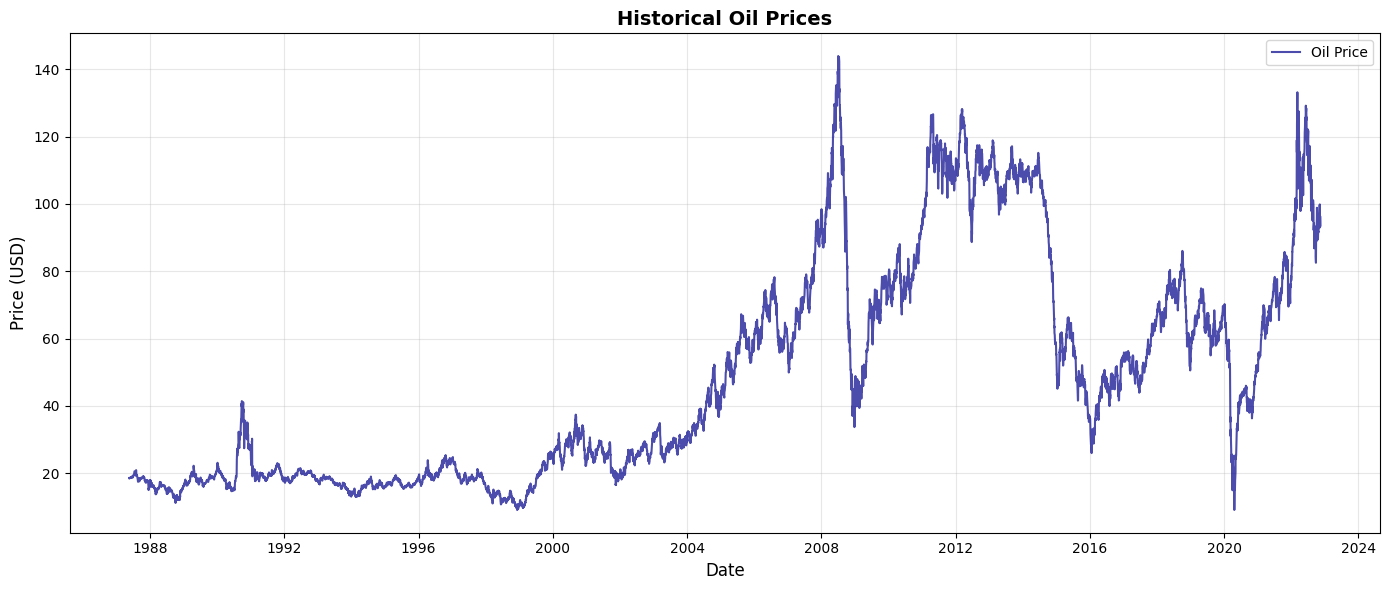

In [5]:
# Plot time series
print("Time Series Plot:")
plot_time_series(df_clean)

Price Distribution:


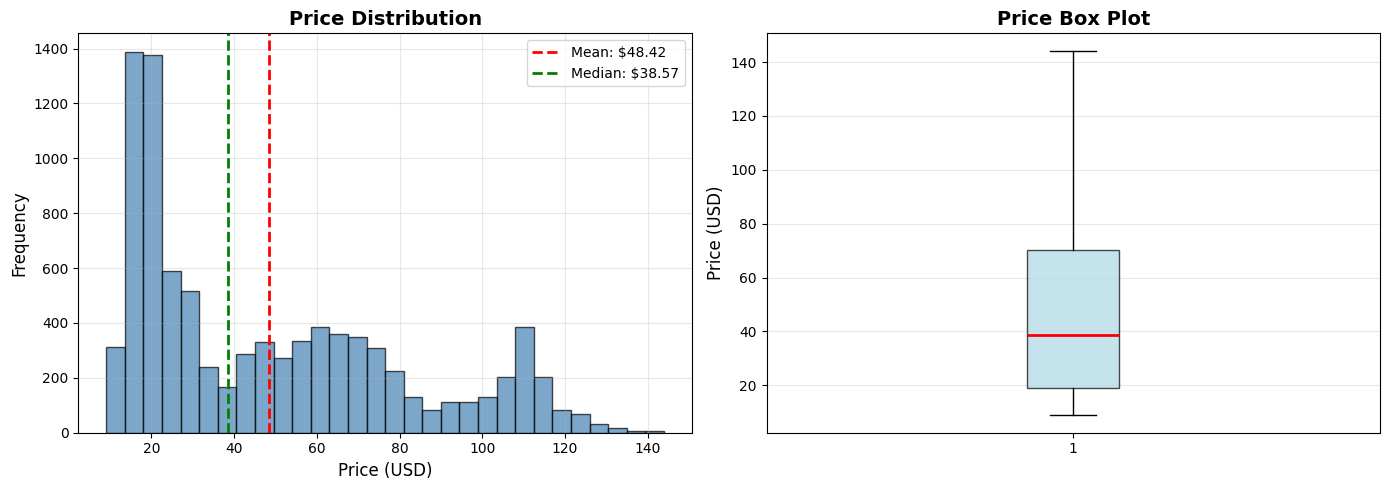

In [6]:
# Plot distribution
print("Price Distribution:")
plot_distribution(df_clean)

Volatility Analysis:


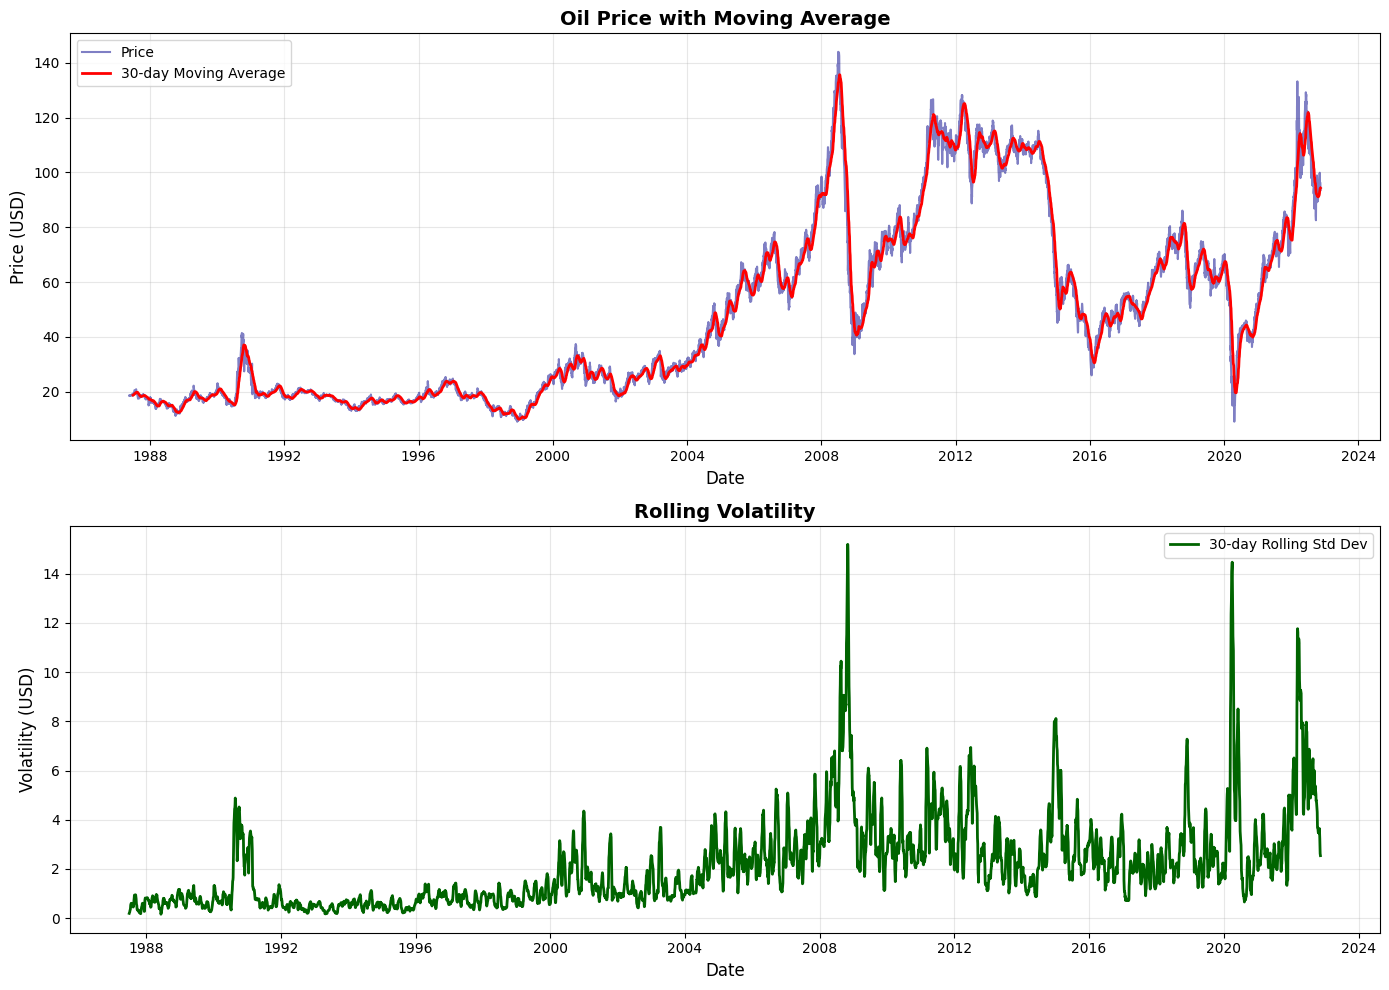

In [7]:
# Plot volatility
print("Volatility Analysis:")
plot_volatility(df_clean, window=30)

---

## Summary

### What We Accomplished in Task 1:

1. ✅ Loaded and cleaned oil price data
2. ✅ Performed exploratory data analysis
3. ✅ Visualized time series, distributions, and volatility

### Next Steps (Task 2):

- Build Bayesian Change Point Model
- Run MCMC sampling
- Generate reports

---

## Save All Visualizations

Run this cell to save all plots to the outputs directory.

Saving all visualizations...

Saved time series plot to ..\outputs\eda_time_series.png


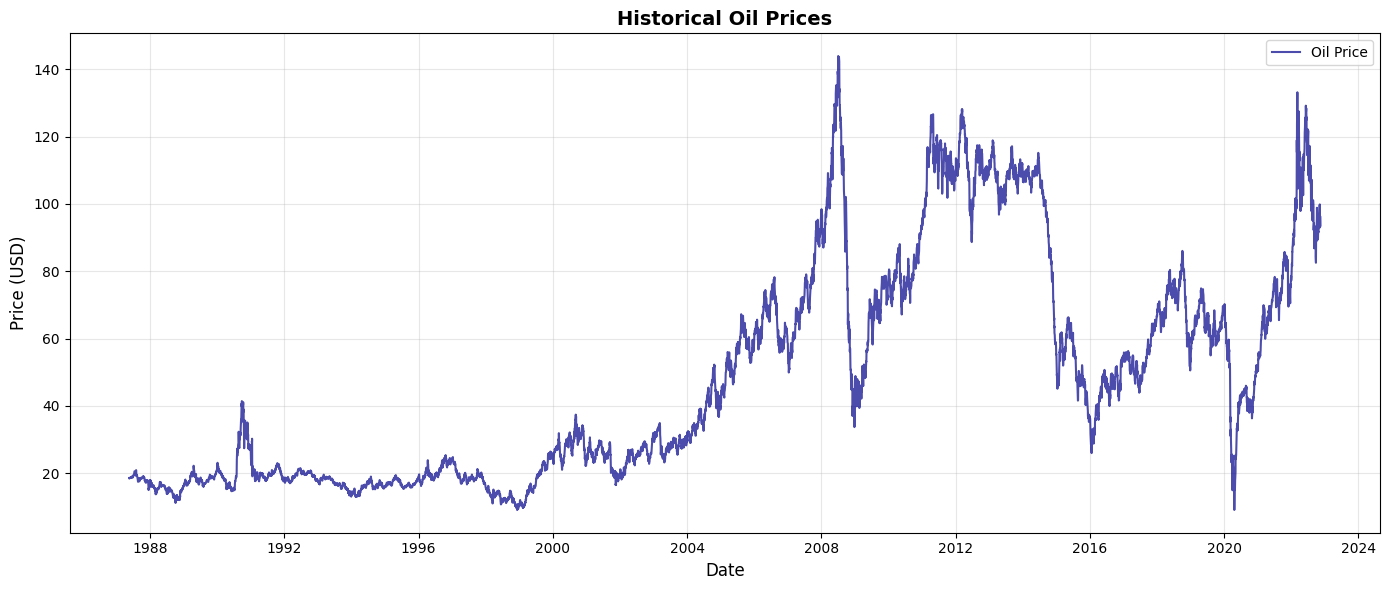

Saved distribution plot to ..\outputs\eda_distribution.png


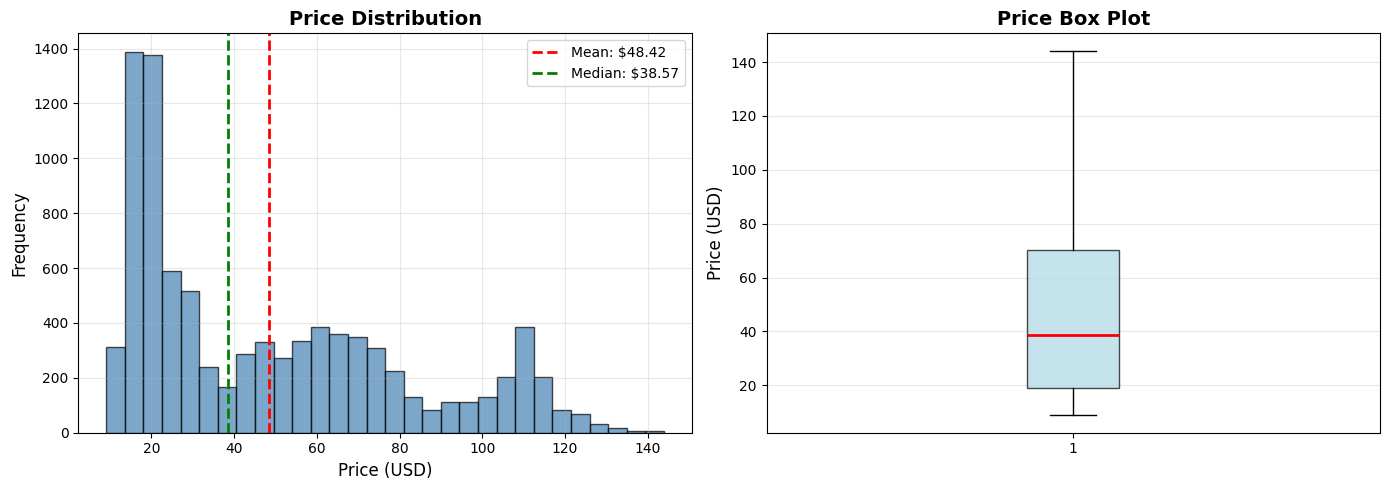

Saved volatility plot to ..\outputs\eda_volatility.png


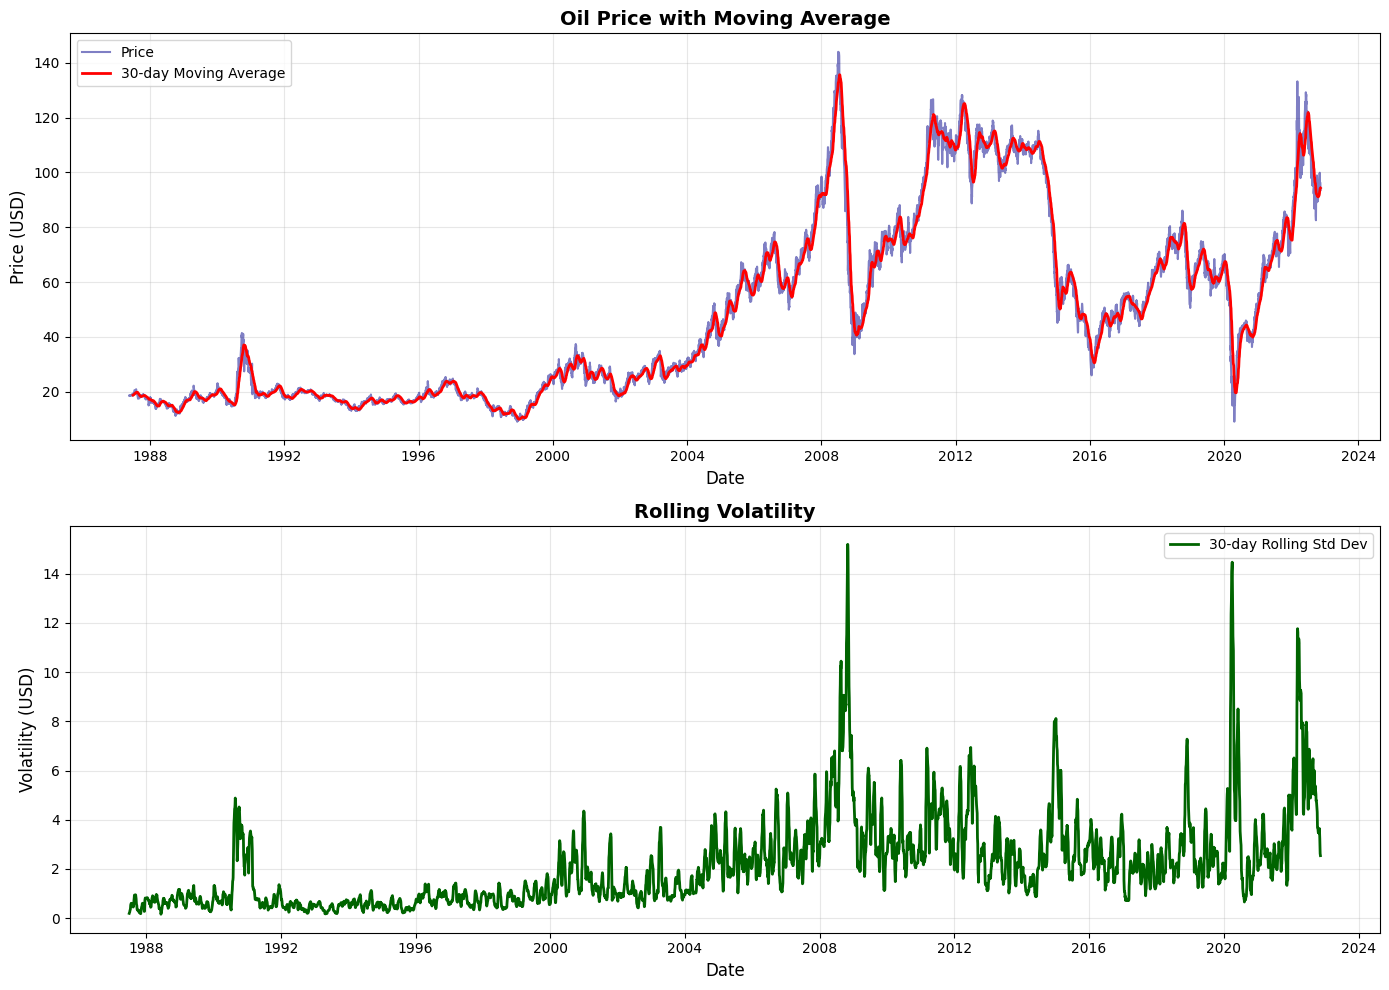


✓ All visualizations saved to: c:\Users\Acer\Documents\KAIM_PROJECT\TEST\oil_price_changepoint\notebooks\..\outputs


In [8]:
# Create outputs directory
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# Save all visualizations
print("Saving all visualizations...\n")

# EDA plots
plot_time_series(df_clean, save_path=output_dir / 'eda_time_series.png')
plot_distribution(df_clean, save_path=output_dir / 'eda_distribution.png')
plot_volatility(df_clean, window=30, save_path=output_dir / 'eda_volatility.png')

print("\n✓ All visualizations saved to:", output_dir.absolute())